# 28. MMPA 통계적 유의성 + 3D 형태 비교 지표

## 이번 노트북에서 할 것
- MMPA 기반 데이터형 발견에 통계적 유의성 검정 추가 (표본 수 적은 core
  그룹 제외 기준 마련)
- RDKit 3D conformer 생성 + 치환 전후 형태(shape) 비교 지표 추가
  (제안서 5번 "본선 시연 시나리오"에 직접 기여 목적)
- 여유 있으면: 전체 데이터(7,823개)로 MMPA 확장, 더미원자 결합환경 개선

## 간략한 정리 (27까지)
- 라이브러리 29개 규칙, 11가지 편집 방식, valid set 커버리지 31.5%
  (목표 30% 돌파)
- 오늘 신규: N-nitroso, hydrazine, sulphate, N_oxide, 2-halo_pyridine,
  disulphide, quinone_A(370)(reduce_multi_bond+재방향족화, 연쇄처리 검증),
  isocyanate(가수분해), triple_bond, stilbene
- 신규 편집 타입 3개: reduce_multi_bond, cleave_bond, remove_atom
- 중복 규칙 병합 4건 추가 (diazo_group, oxime_1, catechol_A(92), chinone_1)
- 다음 확장 예정(학생): beta-keto/anhydride, phthalimide, hydroxamic_acid
  (문헌형), 예상 커버리지 35~36%
- test set은 여전히 미사용

## 다음에 해야 할 것 (오늘 끝나면)
- 최종 valid set 재검증, 학생 승인 시 test set 1회 최종 검증
- 제안서는 학생이 계속 병행 작성 중

In [1]:
# 셀 1
!pip install rdkit -q
!pip install fuzzywuzzy python-Levenshtein -q
!pip install PyTDC --no-deps -q
!pip install PyYAML tqdm requests -q
!pip install openai -q
!pip install chembl_webresource_client -q
!pip install py3Dmol -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00


In [2]:
# 셀 2
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')

!git clone https://{token}@github.com/Dec32th/laidd-2026.git
%cd /content/laidd-2026
!pwd

Cloning into 'laidd-2026'...
remote: Enumerating objects: 328, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 328 (delta 35), reused 52 (delta 24), pack-reused 260 (from 1)
Receiving objects: 100% (328/328), 784.24 KiB | 6.03 MiB/s, done.
Resolving deltas: 100% (172/172), done.
/content/laidd-2026
/content/laidd-2026


In [3]:
# 셀 3
!git config --global user.email "hyekyeong.w@gmail.com"
!git config --global user.name "Dec32th"

In [4]:
# 셀 4
import importlib, random, json
import numpy as np, pandas as pd
from collections import Counter
from scipy import stats
from rdkit import Chem
from rdkit.Chem import rdMMPA, rdFingerprintGenerator, QED, AllChem
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

import src.tools.replacement_library
import src.tools.molecule_editor
import src.tools.atom_editor
import src.tools.toxicophore_detector
import src.tools.agent

from src.tools.data_prep import load_tox21_clean
from src.tools.toxicophore_detector import detect_toxicophores
from src.tools.replacement_library import get_replacement_candidates
from src.tools.molecule_editor import propose_fix, canonicalize, iterative_fix_loop
from src.tools.agent import ask_llm_which_problem_to_fix, ask_llm_which_candidate_to_use
from src.tools.atom_editor import apply_atom_edit_from_rule

data = load_tox21_clean(random_state=7)

_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return _generator.GetFingerprintAsNumPy(mol) if mol else None

print(f"도구 로드 완료. 현재 라이브러리 규칙 수: {len(get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY'])}")

[14:36:49] WARNING: not removing hydrogen atom without neighbors
[14:36:49] Explicit valence for atom # 8 Al, 6, is greater than permitted
[14:36:49] Explicit valence for atom # 3 Al, 6, is greater than permitted
[14:36:49] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:36:50] Explicit valence for atom # 4 Al, 6, is greater than permitted
[14:36:50] Explicit valence for atom # 9 Al, 6, is greater than permitted
[14:36:50] Explicit valence for atom # 5 Al, 6, is greater than permitted
[14:36:50] Explicit valence for atom # 16 Al, 6, is greater than permitted
[14:36:51] Explicit valence for atom # 20 Al, 6, is greater than permitted


전체: 7831개, 파싱 성공: 7823개, 파싱 실패(제외): 8개


[14:36:51] WARNING: not removing hydrogen atom without neighbors


도구 로드 완료. 현재 라이브러리 규칙 수: 30


In [5]:
from openai import OpenAI
dashscope_key = userdata.get('DASHSCOPE_API_KEY')
client_qwen = OpenAI(api_key=dashscope_key, base_url="https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1")
print("Qwen 클라이언트 준비 완료")

Qwen 클라이언트 준비 완료


In [6]:
for rule, info in get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY'].items():
    for c in info['candidates']:
        if 'source' in c and 'data-driven' in c.get('source', ''):
            print(f"{rule}: {c['name']} - {c.get('source')}")

In [7]:
rule_freq_v28 = Counter()
for s in data['smiles_valid']:
    p = detect_toxicophores(s)
    for x in p:
        rule_freq_v28[x['rule_name']] += 1

covered_v28 = set(get_replacement_candidates.__globals__['REPLACEMENT_LIBRARY'].keys())
uncovered_v28 = {r: c for r, c in rule_freq_v28.items() if r not in covered_v28 and c >= 5}
sorted_uncovered_v28 = sorted(uncovered_v28.items(), key=lambda x: -x[1])

print("표본 5개 이상인 미커버 규칙 (MMPA 시도 가능 후보):")
for rule, count in sorted_uncovered_v28:
    print(f"  {rule}: {count}개")

표본 5개 이상인 미커버 규칙 (MMPA 시도 가능 후보):
  Aliphatic_long_chain: 170개
  Oxygen-nitrogen_single_bond: 79개
  isolated_alkene: 65개
  phosphor: 33개
  quaternary_nitrogen_1: 28개
  quaternary_nitrogen_2: 23개
  heavy_metal: 16개
  iodine: 14개
  halogenated_ring_1: 10개
  phenol_ester: 9개
  imine_2: 7개
  polyene: 6개
  Polycyclic_aromatic_hydrocarbon_2: 6개
  acyclic_C=C-O: 6개
  phthalimide: 6개
  >_2_ester_groups: 6개
  imine_1_guanidine: 5개
  cyanate_/aminonitrile_/thiocyanate: 5개
  het_thio_666_A(13): 5개
  anil_no_alk(40): 5개
  halogenated_ring_2: 5개


In [8]:
examples_beta = None
for s in data['smiles_valid']:
    problems = detect_toxicophores(s)
    for p in problems:
        if p['rule_name'] == 'beta-keto/anhydride':
            examples_beta = (s, p['atom_indices'])
            break
    if examples_beta:
        break

print("예시:", examples_beta)
if examples_beta:
    smi, indices = examples_beta
    mol = Chem.MolFromSmiles(smi)
    for idx in indices:
        atom = mol.GetAtomWithIdx(idx)
        print(f"  idx={idx}: {atom.GetSymbol()} (이웃: {[n.GetSymbol() for n in atom.GetNeighbors()]})")

예시: ('CCOC(=O)CC(=O)c1ccccc1', [3, 4, 5, 6, 7])
  idx=3: C (이웃: ['O', 'O', 'C'])
  idx=4: O (이웃: ['C'])
  idx=5: C (이웃: ['C', 'C'])
  idx=6: C (이웃: ['C', 'O', 'C'])
  idx=7: O (이웃: ['C'])


In [9]:
pattern_betaketo = Chem.MolFromSmarts("C(=O)CC(=O)")
mol_beta_test = Chem.MolFromSmiles("CCOC(=O)CC(=O)c1ccccc1")
print("매치:", mol_beta_test.HasSubstructMatch(pattern_betaketo), pattern_betaketo.GetNumAtoms())

# Tox21 train에서 이 패턴을 가진 분자들의 MMPA 치환쌍 수집
beta_pairs = []
for s in data['smiles_train']:
    mol = Chem.MolFromSmiles(s)
    if mol is None or not mol.HasSubstructMatch(pattern_betaketo):
        continue
    frags = rdMMPA.FragmentMol(mol, maxCuts=1, resultsAsMols=False)
    for core, chain in frags:
        if core:
            continue
        parts = chain.split('.')
        if len(parts) != 2:
            continue
        for i, part in enumerate(parts):
            part_mol = Chem.MolFromSmiles(part.replace('[*:1]', 'C'))
            if part_mol and part_mol.HasSubstructMatch(pattern_betaketo):
                beta_pairs.append({"original": s, "core": parts[1-i], "removed": part})
                break

print(f"베타케토 관련 MMPA 조각 확보: {len(beta_pairs)}개")

매치: True 5


[14:37:05] WARNING: not removing hydrogen atom without neighbors


베타케토 관련 MMPA 조각 확보: 274개


In [10]:
def get_charge(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.GetFormalCharge(mol) if mol else None

def get_mw(smiles):
    mol = Chem.MolFromSmiles(smiles)
    from rdkit.Chem import Descriptors
    return Descriptors.MolWt(mol) if mol else None

# core가 같은 것끼리 묶어서, 실제로 여러 다른 removed 조각이 붙는 경우를 찾음
from collections import defaultdict
core_groups = defaultdict(list)
for p in beta_pairs:
    core_groups[p['core']].append(p)

# 표본이 여러 개인 core 그룹만 (통계 검정 가능한 것)
multi_sample_cores = {c: v for c, v in core_groups.items() if len(v) >= 3}
print(f"표본 3개 이상인 core 그룹: {len(multi_sample_cores)}개")

for core, samples in list(multi_sample_cores.items())[:5]:
    print(f"\ncore: {core[:50]}")
    for s in samples[:3]:
        print(f"  removed: {s['removed']}")

표본 3개 이상인 core 그룹: 13개

core: C[*:1]
  removed: CCC1(C[*:1])C(=O)NC(=O)N(C)C1=O
  removed: CCC1(CC)C(=O)NC(=O)N([*:1])C1=O
  removed: CCC1(C[*:1])C(=O)N=C([O-])NC1=O

core: CC[*:1]
  removed: CCC1([*:1])C(=O)NC(=O)N(C)C1=O
  removed: CCC1([*:1])C(=O)N=C([O-])NC1=O
  removed: CCC1([*:1])C(=O)C=CNC1=O

core: CO[*:1]
  removed: Cn1nnnc1SCC1=C(C(=O)O)N2C(=O)[C@](NC(=O)C3SC(=C(C(N)=O)C(=O)O)S3)([*:1])[C@H]2SC1
  removed: COc1cc(Cl)c([*:1])cc1NC(=O)CC(C)=O
  removed: COc1cc(NC(=O)CC(C)=O)c([*:1])cc1Cl

core: O=C(O)[*:1]
  removed: CO[C@@]1(NC(=O)C2SC(=C(C(N)=O)C(=O)O)S2)C(=O)N2C([*:1])=C(CSc3nnnn3C)CS[C@@H]21
  removed: CN(C)[C@@H]1C(O)=C(C(=O)NCN[C@@H](CCCCN)[*:1])C(=O)[C@@]2(O)C(O)=C3C(=O)c4c(O)cccc4[C@@](C)(O)C3C[C@@H]12
  removed: CCCCC1(COC(=O)CC[*:1])C(=O)N(c2ccccc2)N(c2ccccc2)C1=O

core: Cl[*:1]
  removed: O=C(O)C1(C(=O)Nc2ccc([*:1])cc2Cl)CC1
  removed: O=C(O)C1(C(=O)Nc2ccc(Cl)cc2[*:1])CC1
  removed: O=C1N=C2SCCN2C(=O)C1Cc1ccc([*:1])cc1


In [11]:
def core_heavy_atoms(core_smiles):
    mol = Chem.MolFromSmiles(core_smiles.replace('[*:1]', 'C'))
    return mol.GetNumHeavyAtoms() if mol else 0

# core가 충분히 커서(예: 8개 이상 heavy atom) 의미있는 비교가 되는 그룹만 필터
valid_core_groups = {c: v for c, v in multi_sample_cores.items() if core_heavy_atoms(c) >= 8}
print(f"유의미한 core 그룹(원자 8개 이상): {len(valid_core_groups)}개")

for core, samples in list(valid_core_groups.items())[:5]:
    print(f"\ncore({core_heavy_atoms(core)}개 원자): {core[:60]}")
    for s in samples[:3]:
        print(f"  removed: {s['removed'][:60]}")

유의미한 core 그룹(원자 8개 이상): 1개

core(8개 원자): Clc1ccc([*:1])cc1
  removed: O=C1N=C2SCCN2C(=O)C1C[*:1]
  removed: O=C1c2ccccc2C(=O)C1[*:1]
  removed: O=C1c2ccccc2C(=O)C1C(=O)C(c1ccccc1)[*:1]


In [12]:
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule

def fetch_chembl_with_names(max_phase_value, limit=500):
    results = molecule.filter(max_phase=max_phase_value).only(
        ['molecule_structures', 'pref_name']
    )[:limit]
    data_list = []
    for r in results:
        struct = r.get('molecule_structures')
        name = r.get('pref_name')
        if struct and struct.get('canonical_smiles'):
            data_list.append({"smiles": struct['canonical_smiles'], "name": name})
    return data_list

print("승인 약물(phase 4) 가져오는 중...")
drugs_with_names = fetch_chembl_with_names(4, limit=500)
print(f"  {len(drugs_with_names)}개 확보")

#베타 케토/무수물 함유 약물 승인 확인
target_beta = Chem.MolFromSmarts("C(=O)CC(=O)")
beta_drugs = [d for d in drugs_with_names if Chem.MolFromSmiles(d['smiles']) and Chem.MolFromSmiles(d['smiles']).HasSubstructMatch(target_beta)]
print(f"베타케토 함유 승인약물: {len(beta_drugs)}개")
for d in beta_drugs:
    print(f"  {d['name']}: {d['smiles'][:60]}")

승인 약물(phase 4) 가져오는 중...
  498개 확보
베타케토 함유 승인약물: 20개
  THIAMYLAL: C=CCC1(C(C)CCC)C(=O)NC(=S)NC1=O
  THIOPENTAL: CCCC(C)C1(CC)C(=O)NC(=S)NC1=O
  CYCLOBARBITAL: CCC1(C2=CCCCC2)C(=O)NC(=O)NC1=O
  METHOHEXITAL: C=CCC1(C(C)C#CCC)C(=O)NC(=O)N(C)C1=O
  PHENOBARBITAL: CCC1(c2ccccc2)C(=O)NC(=O)NC1=O
  BARBITAL: CCC1(CC)C(=O)NC(=O)NC1=O
  SECOBARBITAL: C=CCC1(C(C)CCC)C(=O)NC(=O)NC1=O
  PENTOBARBITAL: CCCC(C)C1(CC)C(=O)NC(=O)NC1=O
  AMOBARBITAL: CCC1(CCC(C)C)C(=O)NC(=O)NC1=O
  HEXOBARBITAL: CN1C(=O)NC(=O)C(C)(C2=CCCCC2)C1=O
  BUTABARBITAL: CCC(C)C1(CC)C(=O)NC(=O)NC1=O
  APROBARBITAL: C=CCC1(C(C)C)C(=O)NC(=O)NC1=O
  METHARBITAL: CCC1(CC)C(=O)NC(=O)N(C)C1=O
  BUTALBITAL: C=CCC1(CC(C)C)C(=O)NC(=O)NC1=O
  PHENYLBUTAZONE: CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O
  PHENINDIONE: O=C1c2ccccc2C(=O)C1c1ccccc1
  ANISINDIONE: COc1ccc(C2C(=O)c3ccccc3C2=O)cc1
  FLUINDIONE: O=C1c2ccccc2C(=O)C1c1ccc(F)cc1
  THIOPENTAL SODIUM: CCCC(C)C1(CC)C(=O)[N-]C(=S)NC1=O.[Na+]
  METHOHEXITAL SODIUM: C=CCC1(C(C)C#CCC)C(=O)N=C([O

In [13]:
barbiturate_smiles = [d['smiles'] for d in beta_drugs if 'BARBITAL' in d['name'] or 'BARBITON' in d['name']
                       or d['name'] in ['THIAMYLAL', 'THIOPENTAL', 'CYCLOBARBITAL', 'METHOHEXITAL',
                                        'PHENOBARBITAL', 'SECOBARBITAL', 'PENTOBARBITAL', 'AMOBARBITAL',
                                        'HEXOBARBITAL', 'APROBARBITAL', 'BUTALBITAL']]
print(f"바르비투레이트 계열: {len(barbiturate_smiles)}개")

pattern_betaketo_ring = Chem.MolFromSmarts("C(=O)NC(=O)")  # 바르비투르산 고리 핵심부

barb_pairs = []
for s in barbiturate_smiles:
    mol = Chem.MolFromSmiles(s)
    if mol is None:
        continue
    frags = rdMMPA.FragmentMol(mol, maxCuts=1, resultsAsMols=False)
    for core, chain in frags:
        if core:
            continue
        parts = chain.split('.')
        if len(parts) != 2:
            continue
        for i, part in enumerate(parts):
            barb_pairs.append({"original": s, "core": parts[1-i], "removed": part})

core_groups_barb = defaultdict(list)
for p in barb_pairs:
    core_groups_barb[p['core']].append(p)

multi_barb = {c: v for c, v in core_groups_barb.items() if len(v) >= 3}
print(f"표본 3개 이상 core 그룹: {len(multi_barb)}개")
for core, samples in list(multi_barb.items())[:3]:
    print(f"\ncore: {core[:60]}")
    for s in samples[:5]:
        print(f"  removed: {s['removed'][:60]}")

바르비투레이트 계열: 13개
표본 3개 이상 core 그룹: 9개

core: C=C[*:1]
  removed: CCCC(C)C1(C[*:1])C(=O)NC(=S)NC1=O
  removed: CCC#CC(C)C1(C[*:1])C(=O)NC(=O)N(C)C1=O
  removed: CCCC(C)C1(C[*:1])C(=O)NC(=O)NC1=O
  removed: CC(C)C1(C[*:1])C(=O)NC(=O)NC1=O
  removed: CC(C)CC1(C[*:1])C(=O)NC(=O)NC1=O

core: C=CC[*:1]
  removed: CCCC(C)C1([*:1])C(=O)NC(=S)NC1=O
  removed: CCC#CC(C)C1([*:1])C(=O)NC(=O)N(C)C1=O
  removed: CCCC(C)C1([*:1])C(=O)NC(=O)NC1=O
  removed: CC(C)C1([*:1])C(=O)NC(=O)NC1=O
  removed: CC(C)CC1([*:1])C(=O)NC(=O)NC1=O

core: CCCC(C)[*:1]
  removed: C=CCC1([*:1])C(=O)NC(=S)NC1=O
  removed: CCC1([*:1])C(=O)NC(=S)NC1=O
  removed: C=CCC1([*:1])C(=O)NC(=O)NC1=O
  removed: CCC1([*:1])C(=O)NC(=O)NC1=O


In [14]:
def core_heavy_atoms(core_smiles):
    mol = Chem.MolFromSmiles(core_smiles.replace('[*:1]', 'C'))
    return mol.GetNumHeavyAtoms() if mol else 0

valid_barb_groups = {c: v for c, v in multi_barb.items() if core_heavy_atoms(c) >= 5}
print(f"의미있는 core 그룹(원자 5개 이상): {len(valid_barb_groups)}개")
for core, samples in valid_barb_groups.items():
    print(f"\ncore({core_heavy_atoms(core)}개): {core[:60]}, 표본 {len(samples)}개")

의미있는 core 그룹(원자 5개 이상): 3개

core(6개): CCCC(C)[*:1], 표본 4개

core(12개): CCC1([*:1])C(=O)NC(=O)NC1=O, 표본 6개

core(13개): C=CCC1([*:1])C(=O)NC(=O)NC1=O, 표본 3개


In [15]:
for core, samples in valid_barb_groups.items():
    print(f"\n=== core({core_heavy_atoms(core)}개 원자): {core} ===")
    for s in samples:
        print(f"  원본: {s['original'][:50]}")
        print(f"  removed: {s['removed']}")


=== core(6개 원자): CCCC(C)[*:1] ===
  원본: C=CCC1(C(C)CCC)C(=O)NC(=S)NC1=O
  removed: C=CCC1([*:1])C(=O)NC(=S)NC1=O
  원본: CCCC(C)C1(CC)C(=O)NC(=S)NC1=O
  removed: CCC1([*:1])C(=O)NC(=S)NC1=O
  원본: C=CCC1(C(C)CCC)C(=O)NC(=O)NC1=O
  removed: C=CCC1([*:1])C(=O)NC(=O)NC1=O
  원본: CCCC(C)C1(CC)C(=O)NC(=O)NC1=O
  removed: CCC1([*:1])C(=O)NC(=O)NC1=O

=== core(12개 원자): CCC1([*:1])C(=O)NC(=O)NC1=O ===
  원본: CCC1(C2=CCCCC2)C(=O)NC(=O)NC1=O
  removed: C1=C([*:1])CCCC1
  원본: CCC1(c2ccccc2)C(=O)NC(=O)NC1=O
  removed: c1ccc([*:1])cc1
  원본: CCC1(CC)C(=O)NC(=O)NC1=O
  removed: CC[*:1]
  원본: CCCC(C)C1(CC)C(=O)NC(=O)NC1=O
  removed: CCCC(C)[*:1]
  원본: CCC1(CCC(C)C)C(=O)NC(=O)NC1=O
  removed: CC(C)CC[*:1]
  원본: CCC(C)C1(CC)C(=O)NC(=O)NC1=O
  removed: CCC(C)[*:1]

=== core(13개 원자): C=CCC1([*:1])C(=O)NC(=O)NC1=O ===
  원본: C=CCC1(C(C)CCC)C(=O)NC(=O)NC1=O
  removed: CCCC(C)[*:1]
  원본: C=CCC1(C(C)C)C(=O)NC(=O)NC1=O
  removed: CC(C)[*:1]
  원본: C=CCC1(CC(C)C)C(=O)NC(=O)NC1=O
  removed: CC(C)C[*:1]


In [16]:
X_train, y_train, w_train = data['X_train'], data['y_train'], data['w_train']
task_cols = data['task_cols']
classifiers = {}
for i, task in enumerate(task_cols):
    train_mask = w_train[:, i] == 1
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    clf.fit(X_train[train_mask], y_train[train_mask, i])
    classifiers[task] = clf
print("Tox21 baseline 완료")

Tox21 baseline 완료


In [17]:
pairs_to_check = [
    ("C=CCC1(C(C)CCC)C(=O)NC(=S)NC1=O", "C=CCC1(C(C)CCC)C(=O)NC(=O)NC1=O", "THIAMYLAL vs SECOBARBITAL"),
    ("CCCC(C)C1(CC)C(=O)NC(=S)NC1=O", "CCCC(C)C1(CC)C(=O)NC(=O)NC1=O", "THIOPENTAL vs PENTOBARBITAL"),
]

for smi_s, smi_o, label in pairs_to_check:
    fp_s = smiles_to_ecfp(smi_s).reshape(1,-1)
    fp_o = smiles_to_ecfp(smi_o).reshape(1,-1)
    tox21_s = np.mean([classifiers[t].predict_proba(fp_s)[0][1] for t in task_cols])
    tox21_o = np.mean([classifiers[t].predict_proba(fp_o)[0][1] for t in task_cols])
    print(f"\n{label}")
    print(f"  Tox21 평균: 티오형(C=S)={tox21_s:.3f}, 옥소형(C=O)={tox21_o:.3f}, 변화={tox21_o-tox21_s:+.3f}")


THIAMYLAL vs SECOBARBITAL
  Tox21 평균: 티오형(C=S)=0.031, 옥소형(C=O)=0.022, 변화=-0.008

THIOPENTAL vs PENTOBARBITAL
  Tox21 평균: 티오형(C=S)=0.037, 옥소형(C=O)=0.027, 변화=-0.009


In [18]:
pattern_anhydride = Chem.MolFromSmarts("C(=O)OC(=O)")
test_anh = Chem.MolFromSmiles("CC(=O)OC(=O)C")  # 무수아세트산
print("매치:", test_anh.HasSubstructMatch(pattern_anhydride), pattern_anhydride.GetNumAtoms())

매치: True 5


In [19]:
matches_anh = test_anh.GetSubstructMatches(pattern_anhydride)
print("매치 위치:", matches_anh)
for i, idx in enumerate(matches_anh[0]):
    atom = test_anh.GetAtomWithIdx(idx)
    print(f"  패턴위치{i} -> idx{idx}: {atom.GetSymbol()}")

매치 위치: ((1, 2, 3, 4, 5),)
  패턴위치0 -> idx1: C
  패턴위치1 -> idx2: O
  패턴위치2 -> idx3: O
  패턴위치3 -> idx4: C
  패턴위치4 -> idx5: O


In [20]:
%%writefile src/tools/replacement_library.py

REPLACEMENT_LIBRARY = {
    "nitro_group": {
        "problem_smarts": "[N+](=O)[O-]",
        "candidates": [
            {"smiles": "N", "name": "primary amine",
             "rationale": "[참고] 메트로니다졸, 니트로푸란토인, 벤즈니다졸 등 일부 "
                          "항균제/항기생충제는 니트로기의 선택적 환원 활성화 자체가 "
                          "치료 메커니즘이므로, 이런 프로드러그 설계 맥락에서는 본 "
                          "치환이 적절하지 않을 수 있음. || 극성을 유지하면서 니트로기의 "
                          "환원성 대사 중간체 생성 경로를 제거함"},
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "약물유사 골격에서 흔히 쓰이는 안정적 대체기로, 수소결합 donor/acceptor 특성을 일부 유지"},
            {"smiles": "C#N", "name": "nitrile",
             "rationale": "대사 안정성이 개선된 사례가 문헌에 다수 보고됨, 다만 극성은 다소 감소"},
        ],
    },
    "aldehyde": {
        "problem_smarts": "[CX3H1](=O)",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "알데히드의 친전자성(단백질 부가물 형성 우려)을 제거하면서 유사한 형태 유지"},
            {"smiles": "C(O)", "name": "alcohol",
             "rationale": "가장 단순한 환원형 대체, 반응성 크게 감소"},
        ],
    },
    "Michael_acceptor_1": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=CC(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "saturated (C-C single bond)",
             "rationale": "[참고] 에타크린산처럼 시스테인 잔기와의 공유결합 자체가 "
                          "작용 메커니즘인 공유결합 억제제(covalent inhibitor) "
                          "계열에는 본 경고가 그대로 적용되지 않을 수 있음. || "
                          "알파,베타-불포화 카르보닐의 C=C 이중결합을 환원하여 "
                          "단백질 친전자성 부가반응(Michael addition, covalent "
                          "binding) 위험을 제거함"},
        ],
    },
    "acid_halide": {
        "problem_smarts": "C(=O)[F,Cl,Br,I]",
        "candidates": [
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "고반응성 아실할라이드를 안정적인 아마이드로 대체"},
            {"smiles": "C(=O)O", "name": "ester",
             "rationale": "아마이드보다 극성이 낮고 유연한 대체 옵션, 가수분해 속도 조절 가능 (검증 필요)"},
        ],
    },
    "alkyl_halide": {
        "problem_smarts": "[Cl,Br,I]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "[참고] 메클로르에타민, 사이클로포스파미드, 카머스틴, "
                          "클로람부실 등 알킬화 항암제는 DNA 알킬화(반응성) 자체가 "
                          "세포독성 치료 메커니즘이므로, 이 계열에는 본 치환이 "
                          "적절하지 않음. || 이탈기를 제거해 알킬화 반응성을 없앰, "
                          "극성은 유사하게 유지"},
            {"smiles": "F", "name": "fluorine",
             "rationale": "할로겐을 유지하되 C-F 결합은 강해 이탈기로 작용하지 않음, 입체적 크기도 유사"},
        ],
    },
    "aniline": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NH2]c1ccc([#6,#7,#8,#16])cc1",
        "target_idx_in_pattern": 0,
        "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
        "anchor_indices_in_pattern": (0, 5),
        "candidates": [
            {"edit_type": "add_substituent", "param": "C(=O)C",
             "target_idx_in_pattern": 0,
             "name": "acetamide (acylated amine)",
             "rationale": "[참고] 설파계 항생제(설파닐아마이드, 설파메톡사졸 등)와 "
                          "프로카인아마이드처럼 아닐린 골격이 반응성 대사가 아닌 "
                          "안정적 형태로 널리 처방되어 온 사례가 다수 있음. 이 경우 "
                          "특이체질 반응은 드물고 예측이 어려워, 본 경고를 절대적 "
                          "배제 기준이 아닌 참고 신호로 해석해야 함. || 1차 방향족 "
                          "아민을 아마이드로 아실화하여 N-hydroxylation 경로 자체를 차단"},
            {"edit_type": "replace_ring", "param": "[*:1]C12CC(C1)(C2)[*:2]",
             "ring_atom_indices_in_pattern": [1, 2, 3, 4, 6, 7],
             "anchor_indices_in_pattern": (0, 5),
             "name": "BCP (bicyclo[1.1.1]pentane)",
             "rationale": "para-이치환 아닐린의 방향족 벤젠 고리를 포화 bicyclic "
                          "탄소골격(BCP)으로 교체함. 방향족성 제거로 aniline reactive "
                          "metabolite(RM) 형성 및 CYP-inhibition을 감소시켜, 퀴논이민 "
                          "생성 경로를 차단하고 특이체질 약물 부작용(IADR) 위험을 낮춤 "
                          "(문헌 근거, 학생 제공). 벤젠과의 공간적 유사성, Fsp3 증가, "
                          "실제 성공 사례가 많아 채택. 아마이드화(단순 아민 치환)보다 "
                          "변화 폭이 크지만, 물성 개선 효과도 더 큼"},
        ],
    },
    "Sulfonic_acid_2": {
        "problem_smarts": "S(=O)(=O)[OX2H1,OX1-]",
        "candidates": [
            {"smiles": "S(=O)(=O)N", "name": "sulfonamide",
             "rationale": "[참고] 암페타민 설페이트, 사퀴나비르 메실레이트처럼 "
                          "일부 승인약물에서 설폰산/설폰산 유사기는 활성 골격이 "
                          "아니라 염(salt) 형성을 위한 카운터이온으로만 존재함. "
                          "이 경우 본 규칙이 다루는 '독성 유발 골격'과 무관하므로, "
                          "치환 대상 여부를 판단하기 전에 이 산이 활성 골격의 "
                          "일부인지 염 형성용인지 구분이 필요함. || 생리적 pH에서 "
                          "이온화 정도(전하)를 크게 낮춰 세포막 투과성을 개선함. "
                          "설폰산은 대부분 음이온 상태로 존재해 경구 흡수가 저해되는 "
                          "경우가 많으나, 설폰아마이드는 유사한 골격을 유지하면서도 "
                          "중성에 가까워 약물유사성이 개선됨"},
            {"smiles": "C(=O)O", "name": "carboxylic acid",
             "rationale": "설폰산보다 산성도가 약하고 부피가 작은 산성 bioisostere "
                          "(검증 필요)"},
        ],
    },
    "imine_1_oxime": {
        "edit_method": "atom_edit",
        "problem_smarts": "C=N[OX2H1]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "옥심의 C=N 결합을 환원하여, 가수분해 시 원래의 반응성 "
                          "카르보닐(알데히드/케톤)로 되돌아갈 수 있는 대사 불안정 "
                          "경로를 제거함"},
        ],
    },
    "imine_1_general": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX3;!$(C(N)(N)=N)]=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "amine (reduced)",
             "rationale": "일반 이민(C=N-R)을 환원하여 가수분해 시 반응성 카르보닐로 "
                          "되돌아갈 수 있는 대사 불안정 경로를 제거함. 옥심 특유의 "
                          "메커니즘보다는 근거가 다소 약하며, 하위 구조별 개별 검증 필요. "
                          "구아니딘(N-C(=N)-N, 공명구조로 일반 이민과 반응성이 다름)은 "
                          "이 SMARTS에서 명시적으로 제외함"},
        ],
    },
    "catechol": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H;$(Oc1ccccc1O)]",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 도파민, 에피네프린, 이소프로테레놀 등 카테콜아민류 "
                          "약물은 카테콜 구조 자체가 아드레날린/도파민 수용체 결합에 "
                          "필수적인 약효 골격이므로, 이 경우 본 치환은 독성 감소가 "
                          "아니라 약효 상실로 이어짐. || 인체의 COMT(catechol-O-"
                          "methyltransferase) 효소가 카테콜을 메톡시페놀로 메틸화하여 "
                          "해독하는 생리적 경로와 동일한 원리. 오르토-퀴논으로의 산화 "
                          "경로를 차단하여 세포독성/유전독성 우려를 낮춤 (학생 확인 "
                          "예정: ScienceDirect catechol overview, PMC6643002 등 참고)"},
        ],
    },
    "Thiocarbonyl_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "[#6]=[#16]",
        "target_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "carbonyl (O replacing S)",
             "rationale": "[참고] 티오펜탈·티아밀랄(치오바르비투레이트, C=S가 지용성 "
                          "증가로 빠른 마취효과에 기여)과 티오구아닌(퓨린 유사 항대사물, "
                          "황이 작용기전에 필수)처럼 황 원자가 약효/효력에 직접 "
                          "기여하는 경우가 있어, 이 계열에는 본 치환이 부적절할 수 "
                          "있음. || 황을 산소로 대체(티오카르보닐->카르보닐)하는 것은 "
                          "흔한 bioisostere 전략으로, 갑상선 기능 저해 등 황 함유 "
                          "작용기 특유의 대사/독성 우려를 낮춤 (검증 필요, "
                          "thiourea->urea 치환 논리와 동일 계열)"},
        ],
    },
    "thiol_2": {
        "problem_smarts": "[SX2H1]",
        "candidates": [
            {"smiles": "O", "name": "hydroxyl (alcohol)",
             "rationale": "티올의 금속 킬레이팅 및 산화(이황화물/술펜산 형성) 반응성을 "
                          "제거하면서, 극성·수소결합 특성을 유사하게 유지함"},
            {"smiles": "C(=O)N", "name": "amide",
             "rationale": "티올을 아마이드로 대체하여 반응성을 낮추면서 약물유사 골격에서 "
                          "흔히 쓰이는 안정적 작용기로 전환 (검증 필요)"},
        ],
    },
    "thiol_1": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=S)[SX1-]",
        "candidates": [
            {"edit_type": "replace_multi",
             "param": [
                 {"idx_in_pattern": 1, "new_element": 8, "new_charge": 0},
                 {"idx_in_pattern": 2, "new_element": 7, "new_charge": 0},
             ],
             "name": "carbamate (O,N replacing S,S)",
             "rationale": "디티오카바메이트(R-O-C(=S)-S-)를 카바메이트(R-O-C(=O)-N)로 "
                          "전환. 두 황 원자를 각각 산소·질소로 교체하여 금속 킬레이팅 "
                          "능력과 효소 억제 활성(디티오카바메이트류 특유의 살충제성 "
                          "독성 기전)을 제거함 (검증 필요)"},
        ],
    },
    "het-C-het_not_in_ring": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4](O)(O)",
        "candidates": [
            {"edit_type": "remove_substituent",
             "center_idx_in_pattern": 0,
             "remove_idx_in_pattern": 1,
             "upgrade_bond_to_idx_in_pattern": 2,
             "name": "ketone/ester (one alkoxy removed, C=O formed)",
             "rationale": "아세탈/케탈 또는 오르토에스터(탄소 하나에 알콕시기 2개 "
                          "이상)는 가수분해에 민감하여 반응성 카르보닐(케톤/알데히드)로 "
                          "쉽게 분해되며 대사 불안정성을 일으킴. 알콕시기 하나를 제거하고 "
                          "남은 산소를 카르보닐로 승격시켜, 가수분해로 어차피 도달할 "
                          "안정한 최종 형태로 미리 전환함 (검증 필요)"},
        ],
    },
    "hydroquinone": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2H]c1ccc([OX2H,NX3H1,NX3H2])cc1",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "add_substituent", "param": "C", "name": "methoxy",
             "rationale": "[참고] 아세트아미노펜은 정상 용량에서는 안전하며 과다복용 "
                          "시에만 위험한 용량 의존적 사례임. 본 시스템은 치료지수를 "
                          "고려하지 않으므로, 아트로핀·디곡신·와파린처럼 좁은 치료지수를 "
                          "가진 기존 약물 전반에 유사하게 적용되는 한계임. || 파라 "
                          "위치에 OH와 (OH 또는 NH)가 있는 구조(하이드로퀴논/파라-"
                          "아미노페놀 계열)는 산화되어 파라-퀴논 또는 파라-퀴논이민(예: "
                          "아세트아미노펜의 NAPQI)을 형성, 글루타치온 고갈과 단백질 "
                          "공유결합을 통한 간독성 위험이 있음"},
        ],
    },
    "azo_A(324)": {
        "edit_method": "atom_edit",
        "problem_smarts": "N=N",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "hydrazine (reduced)",
             "rationale": "아조기(N=N)는 체내에서 아조환원효소에 의해 환원되어 두 개의 "
                          "방향족 아민으로 분해되며, 그 중 일부(벤지딘류 등)가 발암성을 "
                          "가지는 것으로 잘 알려짐(아조 색소의 대표적 독성 메커니즘). "
                          "이중결합을 환원하여 하이드라진 형태로 전환, 완전한 아민 "
                          "분해 경로 자체를 차단함 (검증 필요: 하이드라진 자체의 "
                          "잔여 반응성은 추가 확인 필요)"},
        ],
    },
    "Three-membered_heterocycle": {
        "edit_method": "atom_edit",
        "problem_smarts": "[CX4]1[OX2][CX4]1",
        "candidates": [
            {"edit_type": "open_epoxide", "break_pair_in_pattern": (1, 2),
             "name": "vicinal diol (ring-opened)",
             "rationale": "에폭시드(3원자 고리, 옥시란)는 고리 변형(strain)으로 인해 "
                          "친핵체(DNA, 단백질)와 쉽게 반응하는 알킬화제로 작용함. "
                          "체내 에폭시드 가수분해효소(epoxide hydrolase)가 실제로 "
                          "수행하는 반응과 동일하게 고리를 열어 비시날 디올(vicinal "
                          "diol)로 전환, 반응성을 제거함"},
        ],
    },
    "diketo_group": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)C(=O)",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alpha-hydroxy ketone (reduced)",
             "rationale": "비시날 알파-디케톤(1,2-diketone)은 반응성이 높은 친전자체로 "
                          "단백질과 부가물을 형성할 수 있으며, 흡입 시 호흡기 독성을 "
                          "일으키는 것으로 알려진 디아세틸(버터향 첨가제) 사례가 대표적임. "
                          "카르보닐 하나를 환원하여 알파-하이드록시케톤(아실로인)으로 "
                          "전환, 케토-환원효소에 의한 실제 해독 경로와 유사한 방향으로 "
                          "반응성을 낮춤 (검증 필요)"},
        ],
    },
    "thioester": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2](C(=O))",
        "target_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "replace_element", "param": 8, "name": "ester (O replacing S)",
             "rationale": "티오에스터의 황을 산소로 대체하여 일반 에스터로 전환. "
                          "티오에스터는 일반 에스터보다 가수분해 반응성이 높고 아실화 "
                          "능력이 강해 단백질 등과 부반응 우려가 있음 (검증 필요)"},
        ],
    },
    "N-nitroso": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2;+0;!$(N(=O)[O-])]=[OX1;+0]",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "N-hydroxylamine (reduced)",
             "rationale": "N-니트로소 화합물(니트로사민)은 대사 활성화(알파-수산화)를 "
                          "거쳐 강력한 알킬화 발암물질을 생성하는 것으로 잘 알려짐 "
                          "(발사르탄, 라니티딘 등 실제 의약품 불순물 리콜 사례). "
                          "N=O를 환원하여 반응성을 낮춤 (검증 필요: 완전한 해독은 "
                          "탈니트로소화가 필요하며 이는 근사적 접근)"},
        ],
    },
    "hydrazine": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX3H2][NX3H1]",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 0,
             "center_idx_in_pattern": 1,
             "name": "amide/amine (terminal N removed)",
             "rationale": "하이드라진/하이드라지드(R-NH-NH2)의 말단 질소를 제거하여 "
                          "단순 아민 또는 아마이드로 되돌림. 하이드라진류는 대사 시 "
                          "반응성 디아제늄 중간체를 형성해 유전독성을 일으킬 수 있는 "
                          "것으로 알려짐. 이는 azo_A(324) 환원 시 생성되는 하이드라진 "
                          "중간체의 잔여 위험을 추가로 낮추는 후속 규칙이기도 함 "
                          "(검증 필요)"},
        ],
    },
    "sulphate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[OX2][SX4](=O)(=O)[OX1,OX2H]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "alcohol (sulfate group removed)",
             "rationale": "알킬 설페이트 에스터(R-O-SO3-)는 대사되어 반응성 있는 "
                          "설페이트 이탈기를 통한 알킬화제로 작용할 수 있음(디메틸설페이트가 "
                          "강력한 발암/독성 물질로 잘 알려진 대표 사례). 설페이트기 전체를 "
                          "제거하여 원래의 알코올로 되돌림 (검증 필요)"},
        ],
    },
    "N_oxide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[n+][O-]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 1,
             "center_idx_in_pattern": 0,
             "name": "pyridine (N-oxide removed)",
             "rationale": "방향족 N-옥사이드는 산화적 대사산물이자 반응성 중간체 "
                          "생성 경로의 일부일 수 있음. 산소를 제거하여 원래의 중성 "
                          "방향족 아민(피리딘 등)으로 환원, 자연 대사에서의 환원 "
                          "경로와 유사한 방향으로 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "2-halo_pyridine": {
        "edit_method": "atom_edit",
        "problem_smarts": "n:c(-[Cl,Br,I])",
        "center_idx_in_pattern": 1,
        "candidates": [
            {"edit_type": "remove_atom",
             "remove_idx_in_pattern": 2,
             "center_idx_in_pattern": 1,
             "name": "pyridine (halogen removed)",
             "rationale": "피리딘 고리 질소에 인접한 위치의 할로겐(특히 불소/염소)은 "
                          "친핵성 방향족 치환(SNAr) 반응에 취약해, 체내 친핵체(글루타치온, "
                          "단백질 시스테인 등)와 반응할 수 있음. 할로겐을 제거하고 수소로 "
                          "대체하여 이 반응성 경로를 차단함 (검증 필요)"},
        ],
    },
    "disulphide": {
        "edit_method": "atom_edit",
        "problem_smarts": "[SX2][SX2]",
        "candidates": [
            {"edit_type": "cleave_bond", "cleave_pair_in_pattern": (0, 1),
             "name": "two thiols (bond cleaved)",
             "rationale": "[참고] 이황화결합(S-S)은 시스틴/단백질의 3차구조 형성에 "
                          "필수적인 정상 생체 구조이기도 하므로, 이 결합이 약물의 "
                          "구조 안정성이나 표적 결합에 관여하는 경우 본 치환이 "
                          "부적절할 수 있음. || 디티오카바메이트류(티우람 등) 농약/"
                          "살균제에서 흔한 반응성 이황화결합을 두 개의 티올로 분리, "
                          "산화·금속킬레이팅 반응성을 낮춤 (검증 필요)"},
        ],
    },
    "quinone_A(370)": {
        "edit_method": "atom_edit",
        "problem_smarts": "O=C1C=CC(=O)C=C1",
        "target_pairs_in_pattern": [(1, 0), (4, 5)],
        "ring_atoms_in_pattern": [1, 2, 3, 4, 6, 7],
        "ring_bonds_in_pattern": [(1, 2), (2, 3), (3, 4), (4, 6), (6, 7), (7, 1)],
        "candidates": [
            {"edit_type": "reduce_multi_bond", "name": "hydroquinone (reduced, re-aromatized)",
             "rationale": "파라벤조퀴논은 산화환원 사이클(redox cycling)을 통해 활성산소종(ROS)을 "
                          "생성하고 DNA/단백질과 직접 공유결합하는 대표적 반응성 구조. 체내 "
                          "NQO1(퀴논 환원효소) 효소가 실제로 수행하는 반응과 동일하게 두 카르보닐을 "
                          "환원하고 고리를 재방향족화하여 안정적인 하이드로퀴논으로 전환. 결과물이 "
                          "다시 hydroquinone 규칙에 해당할 수 있으며, 이 경우 반복 루프가 자동으로 "
                          "메톡시페놀 등 산화에 더 안정적인 형태로 한 단계 더 개선함 (검증 필요, "
                          "안트라퀴논 등 융합고리형은 미지원)"},
        ],
    },
    "isocyanate": {
        "edit_method": "atom_edit",
        "problem_smarts": "[NX2]=[CX2]=[OX1]",
        "center_idx_in_pattern": 0,
        "candidates": [
            {"edit_type": "remove_atom",
            "remove_idx_in_pattern": 1,
            "center_idx_in_pattern": 0,
            "name": "amine (NCO hydrolyzed)",
            "rationale": "이소시아네이트(R-N=C=O)는 매우 반응성이 높은 친전자체로, "
                      "단백질/아미노기와 쉽게 부가반응을 일으켜 직업성 천식·과민증을 "
                      "유발하는 것으로 잘 알려짐(TDI, MDI 등 산업용 이소시아네이트 "
                      "사례). 체내/환경에서 실제로 일어나는 가수분해 경로(R-NCO + H2O "
                      "-> R-NH2 + CO2)와 동일하게 카르보닐 탄소와 산소를 제거하고 "
                      "질소만 남겨 아민으로 전환 (검증 필요)"},
        ],
    },
    "triple_bond": {
        "problem_smarts": "C#C",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (0, 1),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "alkene (partially reduced)",
            "rationale": "말단 알카인(삼중결합)은 CYP450 효소에 의해 기계기반 억제"
                      "(mechanism-based inhibition) 경로로 대사되며, 반응성 케텐/"
                      "에폭사이드 중간체를 형성해 효소를 비가역적으로 불활성화할 "
                      "수 있음(에티닐에스트라디올 등에서 알려진 메커니즘). 삼중결합을 "
                      "이중결합으로 환원하여 반응성을 낮춤 (검증 필요, 완전 포화가 "
                      "아닌 부분 환원)"},
        ],
    },
    "stilbene": {
        "problem_smarts": "c-[CX3]=[CX3]-c",
        "edit_method": "atom_edit",
        "target_idx_pair_in_pattern": (1, 2),
        "candidates": [
            {"edit_type": "reduce_bond", "name": "diarylethane (reduced)",
            "rationale": "스틸벤 구조(두 방향족 고리를 잇는 C=C)는 디에틸스틸베스트롤"
                      "(DES)처럼 내분비교란 및 대사 산화를 통한 반응성 중간체 형성이 "
                      "알려진 골격. 이중결합을 환원하여 평면성을 낮추고 대사 반응성을 "
                      "완화함 (검증 필요, 에스트로겐 수용체 결합에 필요한 형태 자체를 "
                      "훼손할 수 있어 신중한 해석 필요)"},
        ],
    },
    "beta-keto/anhydride": {
        "edit_method": "atom_edit",
        "problem_smarts": "C(=O)OC(=O)",
        "center_idx_in_pattern": 2,
        "candidates": [
            {"edit_type": "remove_atom",
            "remove_idx_in_pattern": 3,
            "center_idx_in_pattern": 2,
            "name": "carboxylic acid (anhydride hydrolyzed)",
            "rationale": "산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 "
                      "잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 "
                      "두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. "
                      "한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 "
                      "전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) "
                      "는 문헌 확인 후 추가 예정"},
        ],
    },
}

def get_replacement_candidates(rule_name: str) -> dict | None:
    """rule_name에 해당하는 치환 정보(SMARTS + 후보 리스트)를 반환. 없으면 None."""
    return REPLACEMENT_LIBRARY.get(rule_name)

Overwriting src/tools/replacement_library.py


In [21]:
importlib.reload(src.tools.replacement_library)
importlib.reload(src.tools.atom_editor)
importlib.reload(src.tools.molecule_editor)
from src.tools.molecule_editor import propose_fix

result_anh = propose_fix("CC(=O)OC(=O)C", "beta-keto/anhydride", candidate_idx=0)
print(result_anh)

print("\n=== 회귀 테스트 ===")
print(propose_fix("O=C=Nc1ccc(Cl)c(Cl)c1", "isocyanate", candidate_idx=0))

{'new_smiles': 'CC(=O)O', 'candidate_used': 'carboxylic acid (anhydride hydrolyzed)', 'rationale': "산 무수물(R-C(=O)-O-C(=O)-R')은 강한 아실화제로 단백질 아미노산 잔기와 쉽게 반응하며, 수용액 환경에서 자발적으로 가수분해되어 두 개의 카르복실산으로 분해되는 것이 자연스러운 무독화 경로임. 한쪽 아실기를 제거하여 이 가수분해 최종형(카르복실산)으로 직접 전환 (검증 필요). ※ 대안 후보(무수물->아마이드/이미드 bioisostere) 는 문헌 확인 후 추가 예정", 'is_valid': True}

=== 회귀 테스트 ===
{'new_smiles': 'Nc1ccc(Cl)c(Cl)c1', 'candidate_used': 'amine (NCO hydrolyzed)', 'rationale': '이소시아네이트(R-N=C=O)는 매우 반응성이 높은 친전자체로, 단백질/아미노기와 쉽게 부가반응을 일으켜 직업성 천식·과민증을 유발하는 것으로 잘 알려짐(TDI, MDI 등 산업용 이소시아네이트 사례). 체내/환경에서 실제로 일어나는 가수분해 경로(R-NCO + H2O -> R-NH2 + CO2)와 동일하게 카르보닐 탄소와 산소를 제거하고 질소만 남겨 아민으로 전환 (검증 필요)', 'is_valid': True}


In [22]:
!git add src/tools/replacement_library.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [23]:
!git commit -m "Add beta-keto/anhydride rule (acid anhydride -> carboxylic acid via remove_atom, mirrors spontaneous aqueous hydrolysis to detoxify the strong acylating agent). Amide/imide bioisostere alternative flagged for literature confirmation. Library now 30 rules, 11 edit types."
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [24]:
def get_3d_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    result = AllChem.EmbedMolecule(mol, randomSeed=42)
    if result != 0:
        return None
    AllChem.MMFFOptimizeMolecule(mol)
    return mol

test_orig = "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1"
test_fixed = propose_fix(test_orig, "aniline", candidate_idx=1)['new_smiles']  # BCP 치환

mol_orig_3d = get_3d_mol(test_orig)
mol_fixed_3d = get_3d_mol(test_fixed)

print("원본 3D 생성:", mol_orig_3d is not None)
print("치환 후 3D 생성:", mol_fixed_3d is not None)

원본 3D 생성: True
치환 후 3D 생성: True


In [25]:
from rdkit.Chem import Descriptors3D

def compute_shape_descriptors(mol_3d):
    if mol_3d is None:
        return None
    return {
        "npr1": Descriptors3D.NPR1(mol_3d),  # 정규화 주성분비율 1 (막대형~평면형~구형 판별)
        "npr2": Descriptors3D.NPR2(mol_3d),
        "asphericity": Descriptors3D.Asphericity(mol_3d),
        "eccentricity": Descriptors3D.Eccentricity(mol_3d),
        "radius_of_gyration": Descriptors3D.RadiusOfGyration(mol_3d),
    }

desc_orig = compute_shape_descriptors(mol_orig_3d)
desc_fixed = compute_shape_descriptors(mol_fixed_3d)

print("=== 원본 ===")
for k, v in desc_orig.items():
    print(f"  {k}: {v:.3f}")

print("\n=== 치환 후 (BCP) ===")
for k, v in desc_fixed.items():
    print(f"  {k}: {v:.3f}")

print("\n=== 변화율 ===")
for k in desc_orig:
    change_pct = (desc_fixed[k] - desc_orig[k]) / abs(desc_orig[k]) * 100 if desc_orig[k] != 0 else float('inf')
    print(f"  {k}: {change_pct:+.1f}%")

=== 원본 ===
  npr1: 0.342
  npr2: 0.795
  asphericity: 0.298
  eccentricity: 0.940
  radius_of_gyration: 3.212

=== 치환 후 (BCP) ===
  npr1: 0.368
  npr2: 0.767
  asphericity: 0.269
  eccentricity: 0.930
  radius_of_gyration: 2.980

=== 변화율 ===
  npr1: +7.6%
  npr2: -3.4%
  asphericity: -9.7%
  eccentricity: -1.0%
  radius_of_gyration: -7.2%


In [26]:
def shape_change_summary(original, fixed):
    mol_o = get_3d_mol(original)
    mol_f = get_3d_mol(fixed)
    if mol_o is None or mol_f is None:
        return None
    do = compute_shape_descriptors(mol_o)
    df = compute_shape_descriptors(mol_f)
    rog_change_pct = abs(df['radius_of_gyration'] - do['radius_of_gyration']) / do['radius_of_gyration'] * 100
    asph_change_pct = abs(df['asphericity'] - do['asphericity']) / do['asphericity'] * 100 if do['asphericity'] != 0 else None
    return {"rog_change_pct": rog_change_pct, "asph_change_pct": asph_change_pct}

# 여러 규칙에 대해 샘플 테스트
test_pairs_shape = [
    ("aniline_BCP", "Nc1ccc(NC(=O)c2ccc(N)cc2)cc1", 1),
    ("catechol", "N#CC(C#N)=Cc1ccc(O)c(O)c1", 0),
    ("alkyl_halide", "O=C(O)CCl", 0),
]

results_shape = []
for label, smi, cand_idx in test_pairs_shape:
    rule = "aniline" if "aniline" in label else ("catechol" if "catechol" in label else "alkyl_halide")
    fixed = propose_fix(smi, rule, candidate_idx=cand_idx)
    if fixed and fixed['is_valid']:
        shape_result = shape_change_summary(smi, fixed['new_smiles'])
        print(f"{label}: {shape_result}")
        results_shape.append((label, shape_result))

aniline_BCP: {'rog_change_pct': 7.091852742873001, 'asph_change_pct': 2.9520421678131856}
catechol: {'rog_change_pct': 7.349263452558606, 'asph_change_pct': 6.887923991580494}
alkyl_halide: {'rog_change_pct': 9.261163182277517, 'asph_change_pct': 28.031030868205995}


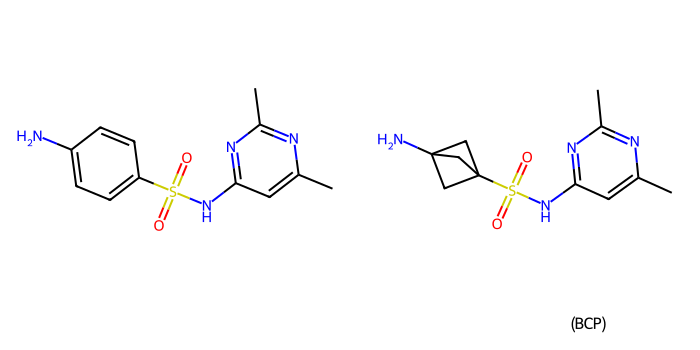

In [27]:
from rdkit.Chem import Draw

def draw_comparison(original_smiles, fixed_smiles, rule_name, candidate_name):
    mol_o = Chem.MolFromSmiles(original_smiles)
    mol_f = Chem.MolFromSmiles(fixed_smiles)
    img = Draw.MolsToGridImage(
        [mol_o, mol_f],
        molsPerRow=2,
        subImgSize=(350, 350),
        legends=[f"원본", f"치환 후 ({candidate_name})"]
    )
    return img

test_orig = "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1"
test_fixed = propose_fix(test_orig, "aniline", candidate_idx=1)['new_smiles']
draw_comparison(test_orig, test_fixed, "aniline", "BCP")

In [28]:
mol_o_ah = get_3d_mol("O=C(O)CCl")
mol_f_ah = get_3d_mol("O=C(O)CO")
desc_o_ah = compute_shape_descriptors(mol_o_ah)
desc_f_ah = compute_shape_descriptors(mol_f_ah)
print("절대값 - 원본:", desc_o_ah)
print("절대값 - 치환후:", desc_f_ah)
print("\n원자 개수 - 원본:", mol_o_ah.GetNumAtoms(), ", 치환후:", mol_f_ah.GetNumAtoms())

절대값 - 원본: {'npr1': 0.18181296158699328, 'npr2': 0.8305978923063736, 'asphericity': 0.5526444250513192, 'eccentricity': 0.9833331312423916, 'radius_of_gyration': 1.6709667982242158}
절대값 - 치환후: {'npr1': 0.27479646186411066, 'npr2': 0.747020675818631, 'asphericity': 0.39773249567376434, 'eccentricity': 0.9615024204581945, 'radius_of_gyration': 1.5162158363189933}

원자 개수 - 원본: 8 , 치환후: 9


In [29]:
import py3Dmol

def show_3d_comparison(original_smiles, fixed_smiles):
    mol_o = get_3d_mol(original_smiles)
    mol_f = get_3d_mol(fixed_smiles)

    mb_o = Chem.MolToMolBlock(mol_o)
    mb_f = Chem.MolToMolBlock(mol_f)

    view = py3Dmol.view(width=800, height=400, viewergrid=(1, 2))
    view.addModel(mb_o, 'mol', viewer=(0, 0))
    view.addModel(mb_f, 'mol', viewer=(0, 1))
    view.setStyle({'stick': {}}, viewer=(0, 0))
    view.setStyle({'stick': {}}, viewer=(0, 1))
    view.zoomTo(viewer=(0, 0))
    view.zoomTo(viewer=(0, 1))
    return view.show()

show_3d_comparison(test_orig, test_fixed)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [30]:
def show_3d_comparison_style(original_smiles, fixed_smiles, style="stick"):
    mol_o = get_3d_mol(original_smiles)
    mol_f = get_3d_mol(fixed_smiles)

    mb_o = Chem.MolToMolBlock(mol_o)
    mb_f = Chem.MolToMolBlock(mol_f)

    view = py3Dmol.view(width=800, height=400, viewergrid=(1, 2))
    view.addModel(mb_o, 'mol', viewer=(0, 0))
    view.addModel(mb_f, 'mol', viewer=(0, 1))

    if style == "sphere":
        view.setStyle({'sphere': {}}, viewer=(0, 0))
        view.setStyle({'sphere': {}}, viewer=(0, 1))
    elif style == "line":
        view.setStyle({'line': {}}, viewer=(0, 0))
        view.setStyle({'line': {}}, viewer=(0, 1))
    elif style == "stick_sphere":
        view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}}, viewer=(0, 0))
        view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}}, viewer=(0, 1))
    elif style == "surface":
        view.setStyle({'stick': {}}, viewer=(0, 0))
        view.setStyle({'stick': {}}, viewer=(0, 1))
        view.addSurface(py3Dmol.VDW, {'opacity': 0.6}, viewer=(0, 0))
        view.addSurface(py3Dmol.VDW, {'opacity': 0.6}, viewer=(0, 1))
    else:  # stick (기본)
        view.setStyle({'stick': {}}, viewer=(0, 0))
        view.setStyle({'stick': {}}, viewer=(0, 1))

    view.zoomTo(viewer=(0, 0))
    view.zoomTo(viewer=(0, 1))
    return view.show()

show_3d_comparison_style(test_orig, test_fixed, style="surface")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [32]:
from rdkit.Chem import Draw

def visualize_fix_process(loop_result, mols_per_row=3, sub_img_size=(300, 300)):
    """iterative_fix_loop의 결과를 받아, 각 단계의 분자 구조를
    규칙/후보/이유와 함께 그리드 이미지로 보여줌."""
    history = loop_result['history']
    mols = []
    legends = []

    for h in history:
        mol = Chem.MolFromSmiles(h['smiles'])
        mols.append(mol)

        if h['step'] == 0:
            legend = "Step 0 (원본)"
        else:
            legend = (f"Step {h['step']}: {h['fixed_rule']}\n"
                      f"-> {h['candidate_used']}")
        legends.append(legend)

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=mols_per_row,
        subImgSize=sub_img_size,
        legends=legends
    )
    return img

상태: success


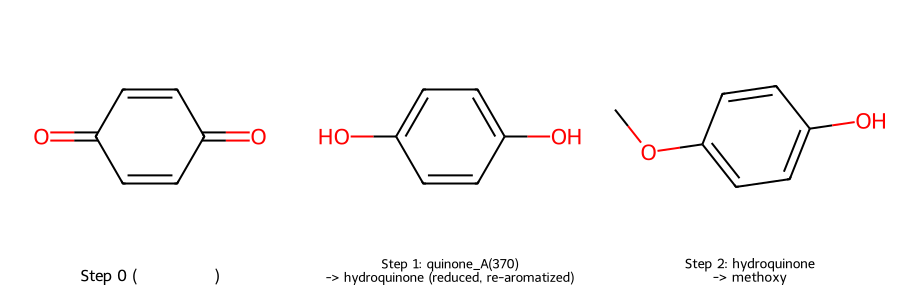

In [35]:
result_demo = iterative_fix_loop("O=C1C=CC(=O)C=C1", max_iterations=5)
print("상태:", result_demo['status'])

img_process = visualize_fix_process(result_demo)
img_process

--- Step 0 ---
SMILES: O=C1C=CC(=O)C=C1

--- Step 1 ---
SMILES: Oc1ccc(O)cc1
고친 문제: quinone_A(370)
문제 선택 이유: 규칙 기반(리스트 순서대로)
선택한 후보: hydroquinone (reduced, re-aromatized)
후보 선택 이유: 규칙 기반(고정 인덱스)

--- Step 2 ---
SMILES: COc1ccc(O)cc1
고친 문제: hydroquinone
문제 선택 이유: 규칙 기반(리스트 순서대로)
선택한 후보: methoxy
후보 선택 이유: 규칙 기반(고정 인덱스)

상태: success


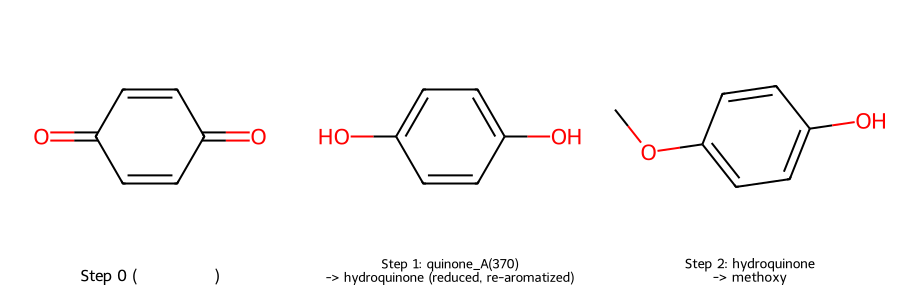

In [36]:
def print_fix_process_detail(loop_result):
    """단계별 구조 + 판단 근거를 텍스트로 상세 출력."""
    for h in loop_result['history']:
        print(f"--- Step {h['step']} ---")
        print(f"SMILES: {h['smiles']}")
        if h['step'] > 0:
            print(f"고친 문제: {h['fixed_rule']}")
            print(f"문제 선택 이유: {h.get('problem_reason', '')}")
            print(f"선택한 후보: {h['candidate_used']}")
            print(f"후보 선택 이유: {h.get('candidate_reason', '')}")
        print()

print_fix_process_detail(result_demo)
result_demo = iterative_fix_loop("O=C1C=CC(=O)C=C1", max_iterations=5)
print("상태:", result_demo['status'])

img_process = visualize_fix_process(result_demo)
img_process

In [37]:
%%writefile src/tools/visualization.py
from rdkit import Chem
from rdkit.Chem import Draw, AllChem


def _truncate(text, max_len=60):
    if text is None:
        return ""
    return text if len(text) <= max_len else text[:max_len] + "..."


def visualize_fix_process(loop_result, mols_per_row=3, sub_img_size=(320, 320)):
    """iterative_fix_loop의 결과를 받아, 각 단계의 분자 구조를
    규칙/후보/판단 이유와 함께 2D 그리드 이미지로 반환.
    치환 과정 중 replace_ring(형태 변화가 핵심 논점인 편집)이 쓰였다면,
    해당 단계의 3D 형태 비교(py3Dmol)도 함께 생성해서 반환한다."""
    from src.tools.replacement_library import get_replacement_candidates

    history = loop_result['history']
    mols = []
    legends = []
    shape_relevant_step = None  # replace_ring이 쓰인 첫 스텝을 기록

    for h in history:
        mol = Chem.MolFromSmiles(h['smiles'])
        mols.append(mol)

        if h['step'] == 0:
            legend = "Step 0 (원본)"
        else:
            reason = _truncate(h.get('candidate_reason', ''), 50)
            legend = f"Step {h['step']}: {h['fixed_rule']}\n-> {h['candidate_used']}\n({reason})"

            rule_info = get_replacement_candidates(h['fixed_rule'])
            if rule_info:
                for c in rule_info.get('candidates', []):
                    if c.get('name') == h['candidate_used'] and c.get('edit_type') == 'replace_ring':
                        if shape_relevant_step is None:
                            shape_relevant_step = h['step']

        legends.append(legend)

    img_2d = Draw.MolsToGridImage(
        mols, molsPerRow=mols_per_row, subImgSize=sub_img_size, legends=legends
    )

    result = {"image_2d": img_2d, "shape_relevant_step": shape_relevant_step}

    if shape_relevant_step is not None:
        prev_smiles = history[shape_relevant_step - 1]['smiles']
        curr_smiles = history[shape_relevant_step]['smiles']
        result["shape_comparison_smiles"] = (prev_smiles, curr_smiles)

    return result


def get_3d_mol(smiles, random_seed=42):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = Chem.AddHs(mol)
    if AllChem.EmbedMolecule(mol, randomSeed=random_seed) != 0:
        return None
    AllChem.MMFFOptimizeMolecule(mol)
    return mol


def show_3d_shape_comparison(original_smiles, fixed_smiles, style="stick"):
    """치환 전후 두 분자를 3D 인터랙티브 뷰(py3Dmol)로 나란히 비교."""
    import py3Dmol

    mol_o = get_3d_mol(original_smiles)
    mol_f = get_3d_mol(fixed_smiles)
    if mol_o is None or mol_f is None:
        return None

    mb_o = Chem.MolToMolBlock(mol_o)
    mb_f = Chem.MolToMolBlock(mol_f)

    view = py3Dmol.view(width=800, height=400, viewergrid=(1, 2))
    view.addModel(mb_o, 'mol', viewer=(0, 0))
    view.addModel(mb_f, 'mol', viewer=(0, 1))

    if style == "surface":
        view.setStyle({'stick': {}}, viewer=(0, 0))
        view.setStyle({'stick': {}}, viewer=(0, 1))
        view.addSurface(py3Dmol.VDW, {'opacity': 0.6}, viewer=(0, 0))
        view.addSurface(py3Dmol.VDW, {'opacity': 0.6}, viewer=(0, 1))
    else:
        view.setStyle({style: {}}, viewer=(0, 0))
        view.setStyle({style: {}}, viewer=(0, 1))

    view.zoomTo(viewer=(0, 0))
    view.zoomTo(viewer=(0, 1))
    return view


def visualize_fix_process_full(loop_result, save_prefix=None):
    """단계별 2D 구조(사유 포함)를 항상 보여주고, replace_ring처럼 형태
    자체가 핵심인 편집이 포함된 경우 3D 형태 비교까지 함께 보여준다.
    save_prefix가 주어지면 이미지를 파일로 저장(예: 'quinone' ->
    'quinone_2d.png', 'quinone_3d_step2.html')."""
    result = visualize_fix_process(loop_result)

    print("=== 단계별 구조 변화 (2D) ===")
    display(result["image_2d"])

    if save_prefix:
        with open(f"{save_prefix}_2d.png", "wb") as f:
            f.write(result["image_2d"].data)
        print(f"저장됨: {save_prefix}_2d.png")

    if result["shape_relevant_step"] is not None:
        print(f"\n=== Step {result['shape_relevant_step']}: 형태 변화가 핵심인 치환 감지, 3D 비교 ===")
        orig, fixed = result["shape_comparison_smiles"]
        view = show_3d_shape_comparison(orig, fixed, style="surface")
        if view:
            view.show()
            if save_prefix:
                html_str = view._make_html()
                with open(f"{save_prefix}_3d_step{result['shape_relevant_step']}.html", "w") as f:
                    f.write(html_str)
                print(f"저장됨: {save_prefix}_3d_step{result['shape_relevant_step']}.html")

    return result

Writing src/tools/visualization.py


### 퀴논 연쇄 처리 ###
=== 단계별 구조 변화 (2D) ===


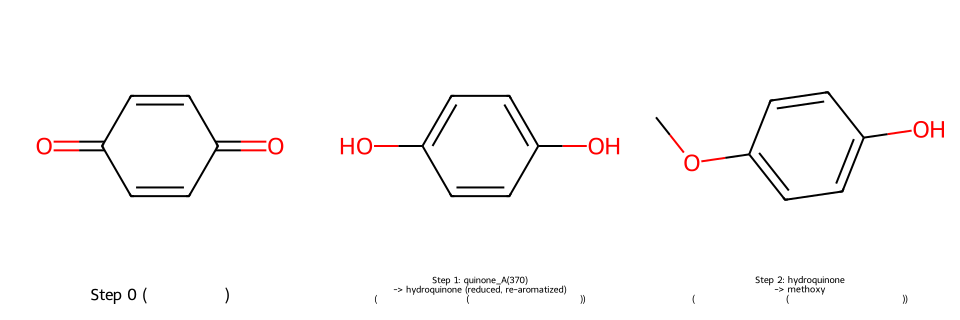

저장됨: quinone_demo_2d.png

### 아닐린 BCP 치환 (LLM 판단) ###
=== 단계별 구조 변화 (2D) ===


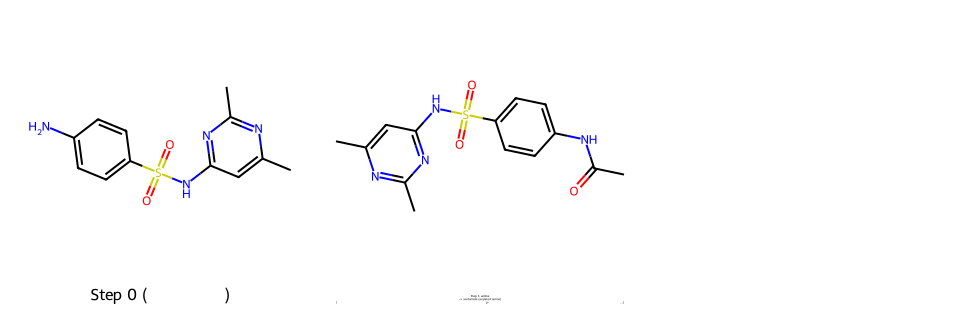

저장됨: aniline_bcp_demo_2d.png


{'image_2d': <IPython.core.display.Image object>, 'shape_relevant_step': None}

In [38]:
importlib.reload(src.tools.visualization) if 'src.tools.visualization' in dir(src.tools) else None
import src.tools.visualization
importlib.reload(src.tools.visualization)
from src.tools.visualization import visualize_fix_process_full

# 퀴논 연쇄 처리 (2D만 나와야 함)
print("### 퀴논 연쇄 처리 ###")
result_quinone_demo = iterative_fix_loop("O=C1C=CC(=O)C=C1", max_iterations=5)
visualize_fix_process_full(result_quinone_demo, save_prefix="quinone_demo")

# 아닐린 BCP (2D + 3D 둘 다 나와야 함)
print("\n### 아닐린 BCP 치환 (LLM 판단) ###")
result_bcp_demo = iterative_fix_loop("Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1", max_iterations=5,
                                       llm_client=client_qwen, llm_model="qwen3.8-max-preview",
                                       llm_client_type="openai_compatible")
visualize_fix_process_full(result_bcp_demo, save_prefix="aniline_bcp_demo")

In [39]:
result_bcp_forced = iterative_fix_loop("Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1", max_iterations=5, candidate_idx=1)
# candidate_idx=1을 지정해도 규칙기반(llm_client 없음)일 때만 적용되니, 확실히 BCP 보려면:
from src.tools.molecule_editor import propose_fix

# 더 확실한 방법: 직접 propose_fix로 BCP 강제 확인
test_smiles = "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1"
bcp_result = propose_fix(test_smiles, "aniline", candidate_idx=1)
print(bcp_result['candidate_used'])

BCP (bicyclo[1.1.1]pentane)


상태: success
Step 1: aniline -> BCP (bicyclo[1.1.1]pentane)
=== 단계별 구조 변화 (2D) ===


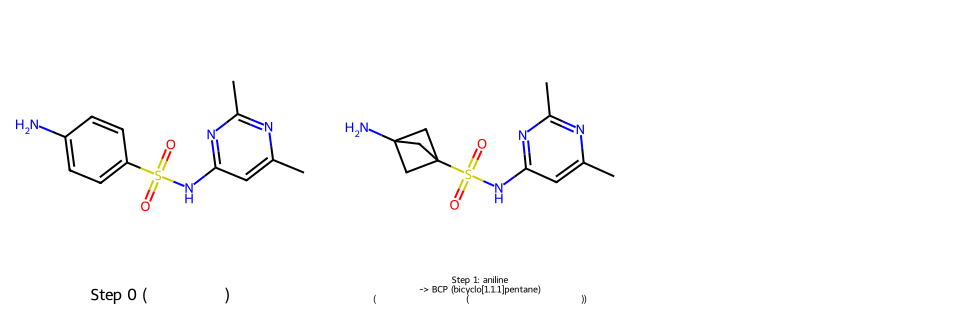

저장됨: aniline_bcp_forced_demo_2d.png

=== Step 1: 형태 변화가 핵심인 치환 감지, 3D 비교 ===


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

저장됨: aniline_bcp_forced_demo_3d_step1.html


{'image_2d': <IPython.core.display.Image object>,
 'shape_relevant_step': 1,
 'shape_comparison_smiles': ('Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1',
  'Cc1cc(NS(=O)(=O)C23CC(N)(C2)C3)nc(C)n1')}

In [41]:
result_bcp_forced_demo = iterative_fix_loop(
    "Cc1cc(NS(=O)(=O)c2ccc(N)cc2)nc(C)n1",
    max_iterations=5,
    candidate_idx=1  # llm_client 없이 규칙기반으로, candidate_idx=1(BCP) 고정
)
print("상태:", result_bcp_forced_demo['status'])
for h in result_bcp_forced_demo['history']:
    if h['step'] > 0:
        print(f"Step {h['step']}: {h['fixed_rule']} -> {h['candidate_used']}")

visualize_fix_process_full(result_bcp_forced_demo, save_prefix="aniline_bcp_forced_demo")

In [42]:
!git add src/tools/visualization.py
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   src/tools/visualization.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	aniline_bcp_demo_2d.png
	aniline_bcp_forced_demo_2d.png
	aniline_bcp_forced_demo_3d_step1.html
	quinone_demo_2d.png



In [43]:
!git commit -m "Add src/tools/visualization.py: visualize_fix_process_full() shows step-by-step 2D structure grid with rule/candidate/reasoning labels for any iterative_fix_loop result, and automatically adds a 3D shape comparison (py3Dmol surface view) when a replace_ring edit (e.g. aniline BCP substitution) is detected in the process — since ring-replacement rationale depends on spatial similarity, not just 2D connectivity. Verified: quinone->hydroquinone->methoxyphenol chain shows 2D only; aniline->BCP shows both 2D and 3D."
!git push origin main

[main d346702] Add src/tools/visualization.py: visualize_fix_process_full() shows step-by-step 2D structure grid with rule/candidate/reasoning labels for any iterative_fix_loop result, and automatically adds a 3D shape comparison (py3Dmol surface view) when a replace_ring edit (e.g. aniline BCP substitution) is detected in the process — since ring-replacement rationale depends on spatial similarity, not just 2D connectivity. Verified: quinone->hydroquinone->methoxyphenol chain shows 2D only; aniline->BCP shows both 2D and 3D.
 1 file changed, 124 insertions(+)
 create mode 100644 src/tools/visualization.py
Enumerating objects: 8, done.
Counting objects: 100% (8/8), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 2.52 KiB | 2.52 MiB/s, done.
Total 5 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/Dec32th/laidd-2026.git
   cbd8484..d34